# Decision Trees
Decision Trees are a type of supervised machine learning algorithm used for both classification and regression tasks. They work by recursively splitting the data into subsets based on the values of input features, creating a tree-like structure where each internal node represents a decision based on a feature, each branch represents the outcome of that decision, and each leaf node represents a final prediction or output. Decision Trees are easy to interpret and visualize, making them popular for various applications such as customer segmentation, fraud detection, and medical diagnosis. However, they can be prone to overfitting if not properly pruned or regulated. Example:

                         Age > 30?        (Root Node)
                       /          \
                     Yes           No
                     /              \
                Income > 50K?     Student?   (Internal Node) 
                /        \         /     \
              Yes        No     Yes       No        (Branch) 
              /           \      /         \
            Buy       Not Buy  Buy       Not Buy    (Leaf Node)

#### Why Decision Trees?
- Simple & intuitive
- Easy to visualize
- Handles both numerical & categorical data
- Requires little data preprocessing

### Strengths of Decision Trees
- Highly explainable and interpretable
- No feature scaling required
- Non-linear relationships can be captured
- Excellent baseline model for many tasks

### Weaknesses of Decision Trees
- If tre grow too deep, it creates a tendency to overfit the training data
- High variance: small changes in data can lead to different splits
- Requires pruning(means cutting back the tree or reducing its size) to avoid overfitting
- Struggle with high dimensional data

### Tree Structure
- Root Node: The topmost node representing the entire dataset. It's the most significant feature that splits the data.
- Internal Nodes: Nodes that represent features used to split the data further.
- Branches: Connections between nodes that represent the outcome of a decision.
- Leaf Nodes: Terminal nodes that represent the final output or decision.

#### How Does a Tree Choose a Split?

At each node, the algorithm evaluates many possible questions to ask about the data. It systematically tests different features and thresholds. The goal is to find the split that results in the most homogeneous subsets, meaning that the data points within each subset are as similar as possible regarding the target variable. This is often achieved using metrics like Gini impurity, Information Gain, or Mean Squared Error (for regression tasks). 

Example: If we have a dataset of people with features like age, income, and student status, the algorithm might first ask, "Is age > 30?" to split the data into two groups. Then, for each group, it might ask further questions like "Is income > 50K?" or "Is the person a student?" to continue splitting the data until it reaches a stopping criterion, such as a maximum tree depth or a minimum number of samples per leaf node.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split


# Load dataset
data = {
    'Weather': ['Sunny', 'Rainy', 'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Sunny', 'Rainy'],
    'Windy':   [0,        1,       0,        1,        0,        1,        0,       1],
    'Play':    [1,        0,       1,        1,        0,        0,        1,       0]
}
df_synthetic = pd.DataFrame(data)
df_synthetic['Weather'] = df_synthetic['Weather'].map({'Sunny': 0, 'Rainy': 1})         # Encode categorical variable
X = df_synthetic[['Weather', 'Windy']]          # Features
y = df_synthetic['Play']                 # Target variable(Play or Not Play depending on weather and windy conditions)

# Train a simple Descision Tree Classifier
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X, y)

DecisionTreeClassifier(random_state=42)

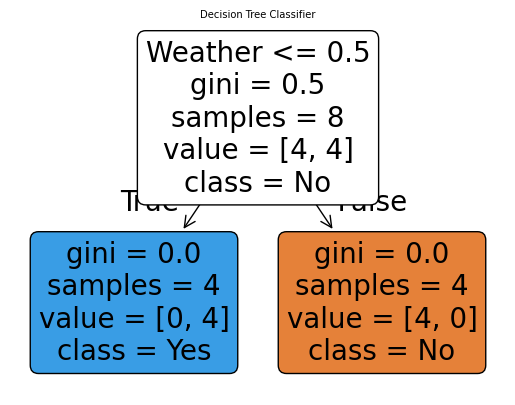

In [16]:
# Visualize the decision tree
plot_tree(tree_clf, feature_names=['Weather', 'Windy'],class_names = ['No', 'Yes'], filled = True, rounded = True,)
plt.title("Decision Tree Classifier")
plt.show()

Let's understand the above deceision tree: Here the model first checks the weather condition. If it's Sunny (0), it predicts Play (1). If it's Rainy (1), it checks if it's Windy. If Windy (1), it predicts Not Play (0); otherwise, it predicts Play (1).


What does these 3boxes mean?

Each box represents a decision node or a leaf node in the decision tree.

The top box is the root node, which checks the 'Weather' feature. In this box we see:
- "Weather <= 0.5": This means if the weather is Sunny (encoded as 0), we go to the left child node; if it's Rainy (encoded as 1), we go to the right child node.
- "gini = 0.5": This is the Gini impurity of the node, a measure of how mixed the classes are in this node. A Gini impurity of 0 means all samples belong to one class, while a Gini impurity of 0.5 means the classes are perfectly mixed.
- "samples = 8": This indicates that there are 8 samples (data points)  at this node.
- "value = [4, 4]": This shows the distribution of classes at this node. Here, there are 4 samples of class 0 (Not Play) and 4 samples of class 1 (Play).
- "class = No": This indicates the predicted class for this node if it were to be a leaf node. In this case, it predicts class 0 (Not Play) because the majority class is 0.

The left child node (for Sunny weather) shows:
- "gini = 0.0": This means all samples in this node belong to one class (Play).
- "samples = 4": There are 4 samples at this node. 
- "value = [0, 4]": All 4 samples belong to class 1 (Play).
- "class = Yes": The predicted class is 1 (Play).

The right child node (for Rainy weather) shows:
- "gini = 0.5": This indicates a mix of classes at this node.
- "samples = 4": There are 4 samples at this node.
- "value = [4, 0]": All 4 samples belong to class 0 (Not Play).
- "class = No": The predicted class is 0 (Not Play).

In [14]:
# Predict on a new sample
new_sample = pd.DataFrame([[0, 1]], columns=['Weather', 'Windy'])  # Sunny and Windy
prediction = tree_clf.predict(new_sample)
print("Prediction for new sample (Sunny, Windy):", "Play" if prediction[0] == 1 else "Not Play")

Prediction for new sample (Sunny, Windy): Play


## Impurity
Impurity is a measure of how mixed the classes are in a dataset. In decision trees, impurity is used to determine the best splits at each node. The goal is to reduce impurity as much as possible with each split, leading to more homogeneous subsets of data. Create as many pure groups(all samples in a group belong to the same class) as possible over mixed groups(samples in a group belong to different classes).

1. Pure Node: A node where all samples belong to the same class. Impurity is 0.
2. Impure Node: A node where samples belong to different classes. Impurity is greater than 0.

Let understand the pure and impure with an example: Let we have a dataset countaing study_hours(int), marks(int) and pass_fail(1/0) columns.
```python
hours = np.arange(1, 11)  # Study hours as feature
marks = np.array([10, 20, 35, 50, 65, 70, 85, 90, 95, 100]) # Continuous target
pass_fail = np.array([0, 0, 0, 1, 1, 1, 0, 0, 1, 1])  # Binary target: 1=Pass, 0=Fail
```
The pass_fail column is our target variable. Now, let's say we split the data. How many students passed if they studied more than 5 hours?
- If we split the data at study_hours > 5, we get:
  - Group 1 (study_hours <= 5): [0, 0, 0, 1, 1] (3 fails, 2 passes) - Impure Node. Why Impure? Because it contains both classes (0 and 1).
  - Group 2 (study_hours > 5): [1, 0, 0, 1, 1] (2 fails, 3 passes) - Impure Node

Like above both groups are impure. Let's split further to get a pure node.
 - Group 4 (study_hours <= 3.5): [0, 0, 0] (3 fails) - Pure Node. Why Pure? Because it contains only one class (0).
 - Group 5 (study_hours > 3.5): [1, 1, 1, 0, 0, 1, 1 ] (5 passes, 2 fails) - Impure Node

Now we set the threshold at 3.5 hours of study. All students who studied less than or equal to 3.5 hours failed, making this a pure node. Then, fail becomes 100% certain for students studying <= 3.5 hours. Now what about the pass? We can further split the impure nodes to try and create more pure nodes.
- If we split the data at study_hours <= 6.5 who also satisfy study_hours <=3.5, we get:
    - Group 5 (study_hours > 3.5 and study_hours <= 6.5): [1, 1, 1] (3 passes) - Pure Node
    - Group 6 (study_hours > 3.5 and study_hours > 6.5): [0, 0, 1, 1] (2 fails, 2 passes) - Impure Node

Now we have another pure node where all students who studied between 3.5 and 6.5 hours passed. Lastly, we can split the last impure node to get more pure nodes.
- If we split the data at study_hours <= 8.5 who also satisfy study_hours > 6.5, we get:
    - Group 6 (study_hours > 6.5 and study_hours <= 8.5): [0, 0] (2 fails) - Pure Node
    - Group 7 (study_hours > 8.5): [1, 1] (2 passes) - Pure Node

Now we have two more pure nodes where all students who studied between 6.5 and 8.5 hours failed, and all students who studied more than 8.5 hours passed.\
So, we get 4 leaf nodes, which represnt a single class aka pure nodes. This is how decision trees use impurity to make splits and create pure nodes in the leaf nodes.


### Entropy
Entropy is a measure of impurity or randomness in a dataset. It quantifies the uncertainty associated with predicting the class of a randomly chosen instance from the dataset. In decision trees, entropy is used to evaluate the quality of splits at each node. The formula for entropy (H) is:

H(S) = - Σ (p(x) * log2(p(x)))

where p(x) is the proportion of instances belonging to class x in the dataset S. A lower entropy value indicates a more homogeneous dataset, while a higher value indicates greater impurity. The goal of the decision tree algorithm is to minimize entropy with each split, leading to more informative and effective decision-making. Entropy ranges from 0 (perfect purity) to log2(c) (maximum impurity), where c is the number of classes. When all instances belong to a single class, entropy is 0, indicating no uncertainty. Conversely, when instances are evenly distributed among all classes, entropy reaches its maximum value, indicating high uncertainty.

### Gini Index
The Gini Index, also known as Gini Impurity, is a measure of statistical dispersion that quantifies the inequality among values of a frequency distribution. In the context of decision trees, it is used to evaluate the quality of splits at each node. The Gini Index ranges from 0 to 0.5, where 0 indicates perfect purity (all instances belong to a single class) and 0.5 indicates maximum impurity (instances are evenly distributed among classes). The formula for calculating the Gini Index (G) is:

G(S) = 1 - Σ (p(x)^2)

where p(x) is the proportion of instances belonging to class x in the dataset S. The goal of the decision tree algorithm is to minimize the Gini Index with each split, leading to more homogeneous subsets of data and improved classification performance. Higher Gini Index values indicate greater impurity, while lower values indicate more purity. Gini use CART(Classification and Regression Trees) algorithm.

### Information Gain
Information Gain is a measure used in decision trees to evaluate the effectiveness of a feature in classifying the data. It quantifies the reduction in uncertainty or impurity achieved by splitting the dataset based on a particular feature. Information Gain is calculated as the difference between the entropy of the original dataset and the weighted average entropy of the subsets created by the split. Meaning, parent impurity - weighted average of child impurities. If this value is high, it means that the feature is effective in reducing uncertainty and is a good candidate for splitting the data at that node. The formula for Information Gain (IG) is:

IG(S, A) = H(S) - Σ (|Sv| / |S|) * H(Sv)

where:
- IG(S, A) is the Information Gain of feature A on dataset S.
- H(S) is the entropy of the original dataset S.
- Sv is the subset of S for which feature A has value v.

Information gain should always be non-negative. With the help of Information Gain, we can choose the best feature to split the data at each node in the decision tree, leading to more effective and accurate classification.

#### Overfitting in Decision Trees
Overfitting in decision trees occurs when the model learns not only the underlying patterns in the training data but also the noise and random fluctuations. This results in a model that performs exceptionally well on the training data but poorly on unseen or test data, as it fails to generalize to new examples. Overfitting can happen when the decision tree is allowed to grow too deep, creating many branches that capture specific details of the training set rather than broader trends. To mitigate overfitting, techniques such as pruning (removing unnecessary branches), setting a maximum depth for the tree, or requiring a minimum number of samples per leaf node can be employed. These methods help create a more balanced model that captures essential patterns without being overly complex.

### Pruning
Pruning is a technique used in decision trees to reduce their size and complexity by removing sections of the tree that do not provide significant predictive power. The goal of pruning is to improve the model's generalization ability and prevent overfitting, which occurs when the tree becomes too complex and captures noise in the training data rather than the underlying patterns. There are two main types of pruning: pre-pruning (or early stopping), which involves setting constraints on the growth of the tree during its construction (such as limiting the maximum depth or minimum samples per leaf), and post-pruning, which involves removing branches from a fully grown tree based on their performance on a validation dataset. By simplifying the decision tree, pruning helps create a more robust model that performs better on unseen data.


### Math on entropy, Gini index, and information gain step by step.


#### Question:

You have a small dataset of 10 students with the following information:

| Student | Study_Hours | Pass |
| ------- | ----------- | ---- |
| 1       | High        | Yes  |
| 2       | High        | Yes  |
| 3       | High        | Yes  |
| 4       | Medium      | Yes  |
| 5       | Medium      | No   |
| 6       | Medium      | No   |
| 7       | Low         | No   |
| 8       | Low         | No   |
| 9       | Low         | No   |
| 10      | Low         | No   |

* Task 1: Compute the entropy of the target variable `Pass`.
* Task 2: Compute the Gini index of `Pass`.
* Task 3: Compute the information gain if you split the data by `Study_Hours`.


#### Solution:

##### Step 1: Entropy of `Pass`

Entropy formula:

```math
H(S) = - \sum_{i} p_i \log_2 p_i
```
Target counts:

* Yes: 4
* No: 6
* Total: 10

Probabilities:
```math
p_{Yes} = 4/10 = 0.4, \quad p_{No} = 6/10 = 0.6
```

Entropy:

```math
H(S) = - (0.4 \log_2 0.4 + 0.6 \log_2 0.6)\\
= - (0.4 \times -1.3219 + 0.6 \times -0.73697)\\
= 0.5288 + 0.4422 = 0.971
```

So, Entropy = 0.971 bits.

##### Step 2: Gini Index of `Pass`

Gini formula:

```math
Gini(S) = 1 - \sum_i p_i^2\\
Gini(S) = 1 - (0.4^2 + 0.6^2) = 1 - (0.16 + 0.36) = 1 - 0.52 = 0.48
```

##### Step 3: Information Gain for `Study_Hours`

Split counts:

* High: 3 Yes, 0 No → total 3
* Medium: 1 Yes, 2 No → total 3
* Low: 0 Yes, 4 No → total 4

Step 3a: Compute entropy for each branch

* High: 
```math 
H = - (1 \log_2 1 + 0 \log_2 0) = 0
```
* Medium: 
```math
p_{Yes}=1/3, p_{No}=2/3\\
  H = - (1/3 \log_2 1/3 + 2/3 \log_2 2/3)\\
  = - ( -0.5283 - 0.38998) = 0.918
  ```
* Low: 
```math
H = - (0 \log_2 0 + 1 \log_2 1) = 0
```

Step 3b: Weighted entropy after split

```math
H_{split} = \frac{3}{10} \times 0 + \frac{3}{10} \times 0.918 + \frac{4}{10} \times 0
= 0.275
```

Step 3c: Information gain

```math
IG = H(S) - H_{split} = 0.971 - 0.275 = 0.696
```

##### Summary

* Entropy of `Pass`: 0.971
* Gini index of `Pass`: 0.48
* Information gain for splitting by `Study_Hours`: 0.696

This shows step-by-step how to calculate entropy, Gini, and IG so you can practice manually for any small dataset.


In [ ]:
# To understand the impurity, entropy, gini index, overfitting, pruning take a bigger dataset and explore more.
from sklearn.datasets import make_classification

X_big, y_big = make_classification(
    n_samples=400,          #Total data points
    n_features=5,           #Total feature number
    n_informative=3,        #Total relevant features
    n_redundant=0,          #No strong correlation among the features
    n_classes=2,            #Target variable/feature class number
    random_state=42,        #Every time we will get the similar random dataset
)

X_train_big, X_test_big, y_train_big, y_test_big = train_test_split(
    X_big, y_big, test_size=0.3, random_state=42
)

X_train_big.shape, X_test_big.shape

((280, 5), (120, 5))

In [33]:
#Train a deep tree vs a pruned tree
deep_tree = DecisionTreeClassifier(random_state=42)
deep_tree.fit(X_train_big, y_train_big)

pruned_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
pruned_tree.fit(X_train_big, y_train_big)

y_train_pred_deep = deep_tree.predict(X_train_big)
y_test_pred_deep = deep_tree.predict(X_test_big)

y_train_pred_pruned = pruned_tree.predict(X_train_big)
y_test_pred_pruned = pruned_tree.predict(X_test_big)

array([[54,  6],
       [ 8, 52]])

array([[54,  6],
       [ 7, 53]])

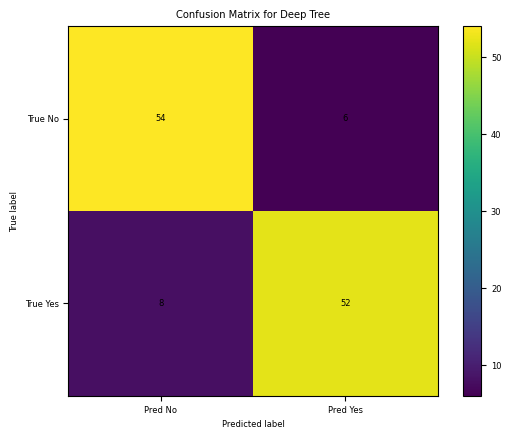

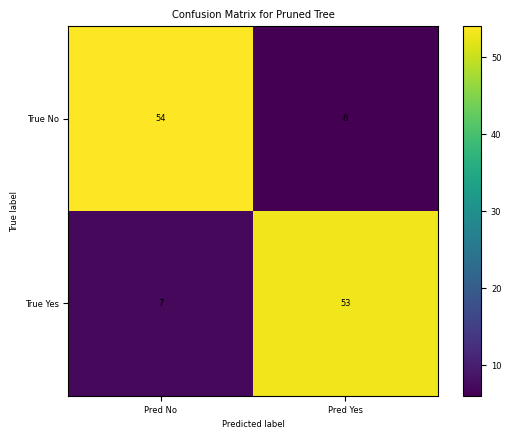

In [34]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

# Deep tree
cm_deep = confusion_matrix(y_test_big, y_test_pred_deep) 
display(cm_deep)   

# Pruned tree
cm_pruned = confusion_matrix(y_test_big, y_test_pred_pruned)
display(cm_pruned)

# Visualize
fig, ax = plt.subplots()
im = ax.imshow(cm_deep, interpolation = 'nearest')
ax.set_title("Confusion Matrix for Deep Tree")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

# Show all ticks and label them
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(["Pred No", "Pred Yes"])
ax.set_yticklabels(["True No", "True Yes"])

# Loop over data dimensions and create text annotations.
for i in range(cm_deep.shape[0]):       #cm_deep.shape gives (2,2); so cm_deep.shape[0] gives number of rows=2
  for j in range(cm_deep.shape[1]):   #cm_deep.shape[1] gives number of columns=2
    ax.text(j,i,cm_deep[i,j], ha='center', va='center')

plt.colorbar(im)
plt.show()

fig, ax = plt.subplots()
im = ax.imshow(cm_pruned, interpolation = 'nearest')
ax.set_title("Confusion Matrix for Pruned Tree")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

# Show all ticks and label them
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(["Pred No", "Pred Yes"])
ax.set_yticklabels(["True No", "True Yes"])

# Loop over data dimensions and create text annotations.
for i in range(cm_pruned.shape[0]):
  for j in range(cm_pruned.shape[1]):
    ax.text(j,i,cm_pruned[i,j], ha='center', va='center')

plt.colorbar(im)
plt.show()

In [35]:
# Classification Report
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score

print('Deep tree - train accuracy:', round(accuracy_score(y_train_big, y_train_pred_deep), 3))
print('Deep tree - test accuracy :', round(accuracy_score(y_test_big, y_test_pred_deep), 3))
print('Deep tree - test precision:', round(precision_score(y_test_big, y_test_pred_deep), 3))
print('Deep tree - test recall   :', round(recall_score(y_test_big, y_test_pred_deep), 3))
print('Deep tree - test f1 score:', round(f1_score(y_test_big, y_test_pred_deep), 3))
print()
print('Pruned tree - train accuracy:', round(accuracy_score(y_train_big, y_train_pred_pruned), 3))
print('Pruned tree - test accuracy :', round(accuracy_score(y_test_big, y_test_pred_pruned), 3))
print('Pruned tree - test precision:', round(precision_score(y_test_big, y_test_pred_pruned), 3))
print('Pruned tree - test recall   :', round(recall_score(y_test_big, y_test_pred_pruned), 3))
print('Pruned tree - test f1 score:', round(f1_score(y_test_big, y_test_pred_pruned), 3))

Deep tree - train accuracy: 1.0
Deep tree - test accuracy : 0.883
Deep tree - test precision: 0.897
Deep tree - test recall   : 0.867
Deep tree - test f1 score: 0.881

Pruned tree - train accuracy: 0.904
Pruned tree - test accuracy : 0.892
Pruned tree - test precision: 0.898
Pruned tree - test recall   : 0.883
Pruned tree - test f1 score: 0.891


Here, it's clearly visible that the deep tree is overfitting the training data as it has 100% accuracy on training set but very low accuracy on test set. On the other hand, the pruned tree has slightly lower accuracy on training set but significantly better accuracy on test set, indicating better generalization to unseen data.

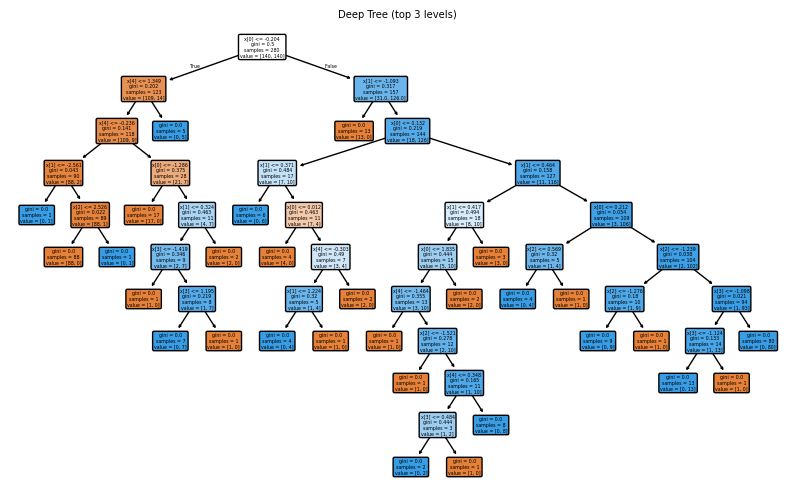

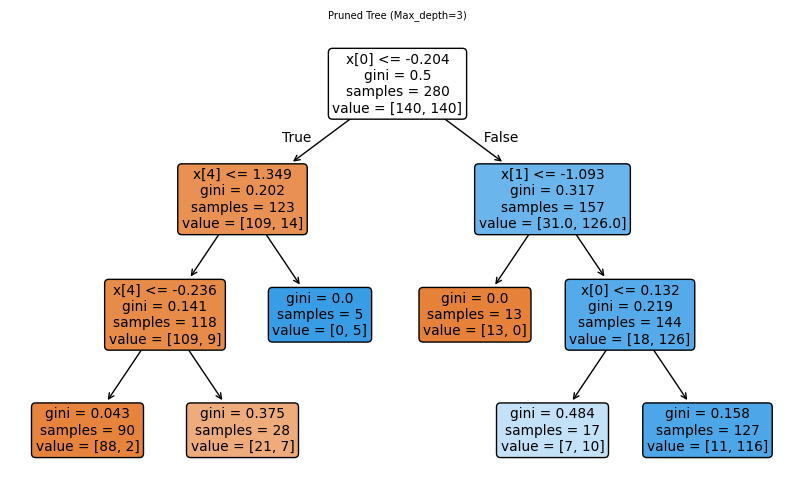

In [ ]:
# Plot deep tree
plt.figure(figsize=(10,6))
plot_tree(deep_tree, filled=True,rounded=True)
plt.title("Deep Tree (top 3 levels)")
plt.show()

# Plot pruned tree
plt.figure(figsize=(10,6))
plot_tree(pruned_tree, filled=True,rounded=True)
plt.title("Pruned Tree (Max_depth=3)")
plt.show()

# If the tree is too deep, the model may overfit the training data, capturing noise instead of the underlying patterns. Pruning helps to reduce the complexity of the tree, improving its generalization to unseen data.

Decision trees and most ML models don't output simple Yes/No predictions. Instead, they generate probability scores that reflect confidence levels. These probabilities provide nuanced information about prediction certainty, enabling more informed clinical decision-making. For instance, a model might predict a 90% chance of disease presence rather than a binary outcome. This allows clinicians to weigh risks and benefits more effectively, tailoring interventions based on the likelihood of outcomes. Utilizing probability scores enhances patient care by facilitating personalized treatment plans and informed decision-making in clinical settings.

### Classification Threshold
The classification threshold is a value that determines the cutoff point for classifying instances into different categories based on predicted probabilities. In binary classification tasks, models often output a probability score between 0 and 1, indicating the likelihood that an instance belongs to a particular class (e.g., positive class). The classification threshold is typically set at 0.5 by default, meaning that if the predicted probability is greater than or equal to 0.5, the instance is classified as belonging to the positive class; otherwise, it is classified as belonging to the negative class. However, this threshold can be adjusted based on the specific requirements of the application, such as prioritizing sensitivity (true positive rate) or specificity (true negative rate). By modifying the classification threshold, one can influence the trade-off between false positives and false negatives, tailoring the model's performance to better suit the context in which it is applied.

## The ROC Curve
The Receiver Operating Characteristic (ROC) curve is a graphical representation used to evaluate the performance of a binary classification model. It plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various classification threshold settings. The TPR, also known as sensitivity or recall, measures the proportion of actual positive instances that are correctly identified by the model, while the FPR measures the proportion of actual negative instances that are incorrectly classified as positive. The ROC curve provides insights into the trade-offs between sensitivity and specificity (1 - FPR) across different thresholds. A model with perfect discrimination will have an ROC curve that passes through the `top-left` corner of the plot, indicating a TPR of 1 and an FPR of 0. The Area Under the ROC Curve (AUC-ROC) is a single scalar value that summarizes the overall performance of the model; an AUC of 1 indicates perfect classification, while an AUC of 0.5 suggests no better performance than random guessing. The ROC curve is widely used in various fields, including medicine and machine learning, to assess and compare the effectiveness of classification models.

AUC(Area Under the Curve): Summarizing the Roc Curve:
- 1: Perfect model
- 0.9: Excellent model
- 0.7: Good model
- 0.5: No better than random guessing

In [21]:
# ROC curve and AOC
from sklearn.metrics import roc_curve, auc

y_test_prob_deep = deep_tree.predict_proba(X_test_big)[:, 1]
y_test_prob_pruned = pruned_tree.predict_proba(X_test_big)[:, 1]

fpr_deep, tpr_deep, _ = roc_curve(y_test_big, y_test_prob_deep)
auc_deep = auc(fpr_deep, tpr_deep)

fpr_pruned, tpr_pruned, _ = roc_curve(y_test_big, y_test_prob_pruned)
auc_pruned = auc(fpr_pruned, tpr_pruned)

print("Deep Tree AUC:", round(auc_deep, 3))
print("Pruned Tree AUC:", round(auc_pruned, 3))

Deep Tree AUC: 0.883
Pruned Tree AUC: 0.922


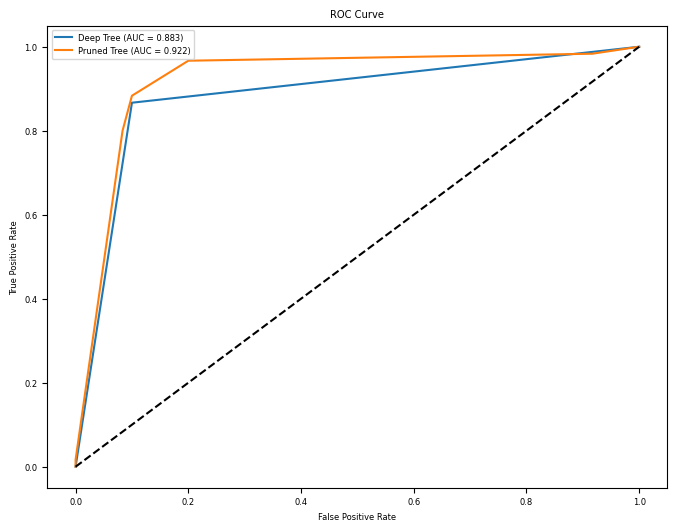

In [22]:
# Visualize
plt.figure(figsize=(8,6))
plt.plot(fpr_deep, tpr_deep, label=f'Deep Tree (AUC = {auc_deep:.3f})')
plt.plot(fpr_pruned, tpr_pruned, label=f'Pruned Tree (AUC = {auc_pruned:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

From the ROC curve is more steep in the pruned tree compared to the deep tree, indicating that the pruned tree has a better trade-off between true positive rate and false positive rate across different thresholds. Additionally, the AUC value for the pruned tree is higher than that of the deep tree, suggesting that the pruned tree has superior overall classification performance. This implies that the pruned tree is more effective at distinguishing between the positive and negative classes, making it a more reliable model for predictions.